<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/Persistency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [4]:

# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'HVz1H6BP'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '11439',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)


In [5]:
import pandas as pd
import numpy as np

# =========================
# CONFIG
# =========================
FILE_PATH = "https://docs.google.com/spreadsheets/d/1SMTl5IIAJl9r0IUm-QsWEEqqQOnTfJMsEBISPaHczj0/export?format=csv"

MA_CONFIG = [
    {"type": "EMA", "length": 10},
    {"type": "EMA", "length": 20},
    {"type": "EMA", "length": 50},
    {"type": "SMA", "length": 200}
]

# =========================
# LOAD DATA
# =========================
'''
df = pd.read_csv(FILE_PATH, parse_dates=["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)
'''
df=nifty_data_format.copy()
# =========================
# FUNCTION: CALCULATE MA
# =========================
def calculate_ma(series, ma_type, length):
    if ma_type == "EMA":
        return series.ewm(span=length, adjust=False).mean()
    elif ma_type == "SMA":
        return series.rolling(window=length).mean()
    else:
        raise ValueError("Unsupported MA type")

# =========================
# FUNCTION: CALCULATE PERSISTENCY
# =========================
def calculate_persistency(close, ma):
    count = np.zeros(len(close))

    for i in range(1, len(close)):
        if close[i] > ma[i]:
            if count[i-1] >= 0:
                count[i] = count[i-1] + 1
            else:
                count[i] = 1

        elif close[i] < ma[i]:
            if count[i-1] <= 0:
                count[i] = count[i-1] - 1
            else:
                count[i] = -1

        else:
            count[i] = count[i-1]

    return count

# =========================
# MAIN LOOP
# =========================
for config in MA_CONFIG:
    ma_type = config["type"]
    length = config["length"]

    ma_col = f"{ma_type}_{length}"
    count_col = f"{ma_col}_count"
    max_col = f"{ma_col}_max"

    # Calculate MA
    df[ma_col] = calculate_ma(df["Close"], ma_type, length)

    # Calculate persistency
    df[count_col] = calculate_persistency(df["Close"].values, df[ma_col].values)

    # Calculate max persistency (rolling max of absolute count)
    df[max_col] = df[count_col].abs().cummax()

    # Entry / Exit signals
    df[f"{ma_col}_entry"] = (df[count_col] == 1).astype(int)
    df[f"{ma_col}_exit"] = (df[count_col] == -1).astype(int)

# =========================
# OVERALL DIRECTION
# =========================
count_cols = [f"{cfg['type']}_{cfg['length']}_count" for cfg in MA_CONFIG]

def get_direction(row):
    positives = sum(row[c] > 0 for c in count_cols)
    negatives = sum(row[c] < 0 for c in count_cols)

    if positives == len(count_cols):
        return "↑"
    elif negatives == len(count_cols):
        return "↓"
    else:
        return "→"

df["Direction"] = df.apply(get_direction, axis=1)

def get_direction(row, threshold=5):
    counts = [row[c] for c in count_cols]

    positives = sum(c > 0 for c in counts)
    negatives = sum(c < 0 for c in counts)

    # Strong uptrend
    if positives == len(counts) and all(c > threshold for c in counts):
        return "↑"

    # Strong downtrend
    elif negatives == len(counts) and all(abs(c) > threshold for c in counts):
        return "↓"

    # Sideways / weak regime
    else:
        return "→"

# =========================
# SAVE OUTPUT
# =========================
df.to_csv("nifty_persistency_output.csv", index=False)

print("Persistency calculation complete.")

Persistency calculation complete.


In [6]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'EMA_10', 'EMA_10_count',
       'EMA_10_max', 'EMA_10_entry', 'EMA_10_exit', 'EMA_20', 'EMA_20_count',
       'EMA_20_max', 'EMA_20_entry', 'EMA_20_exit', 'EMA_50', 'EMA_50_count',
       'EMA_50_max', 'EMA_50_entry', 'EMA_50_exit', 'SMA_200', 'SMA_200_count',
       'SMA_200_max', 'SMA_200_entry', 'SMA_200_exit', 'Direction'],
      dtype='object')

In [7]:
df=df.tail(2500).copy()

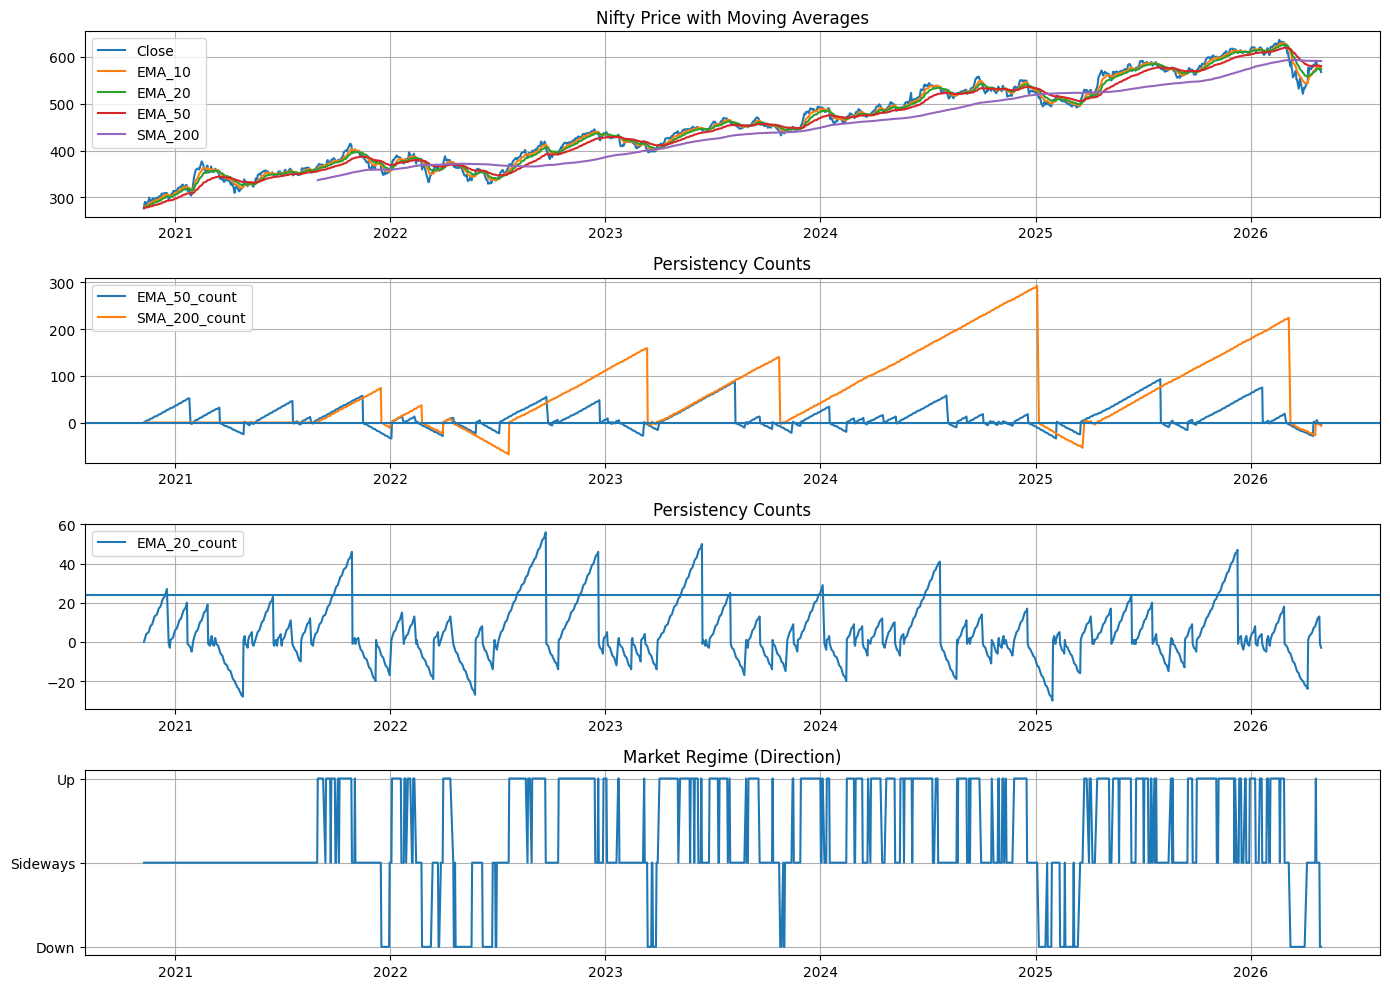

In [8]:

import matplotlib.pyplot as plt

# =========================
# SETUP
# =========================
plt.figure(figsize=(14, 10))

# Create subplots
ax1 = plt.subplot(4, 1, 1)  # Price + MAs
ax2 = plt.subplot(4, 1, 2, sharex=ax1)  # Persistency
ax3 = plt.subplot(4, 1, 3, sharex=ax1)  # Direction
ax4 = plt.subplot(4, 1, 4, sharex=ax1)  # Direction
# =========================
# 1. PRICE + MOVING AVERAGES
# =========================
ax1.plot(df.index, df["Close"], label="Close")

for col in df.columns:
    if "EMA_" in col or "SMA_" in col:
        if "_count" not in col and "_max" not in col and "_entry" not in col and "_exit" not in col:
            ax1.plot(df.index, df[col], label=col)

ax1.set_title("Nifty Price with Moving Averages")
ax1.legend()
ax1.grid()

# =========================
# 2. PERSISTENCY COUNTS
# =========================
count_cols = [c for c in df.columns if "SMA_200_count" in c or "EMA_50_count" in c]

for col in count_cols:
    ax2.plot(df.index, df[col], label=col)

ax2.axhline(0)  # zero line
ax2.set_title("Persistency Counts")
ax2.legend()
ax2.grid()


# =========================
# 2. PERSISTENCY COUNTS
# =========================
count_cols = [c for c in df.columns if "EMA_20_count" in c]

for col in count_cols:
    ax3.plot(df.index, df[col], label=col)

ax3.axhline(24)  # zero line
ax3.set_title("Persistency Counts")
ax3.legend()
ax3.grid()
# =========================
# 3. DIRECTION (REGIME)
# =========================
# Convert arrows to numeric for plotting
direction_map = {"↑": 1, "→": 0, "↓": -1}
df["Direction_num"] = df["Direction"].map(direction_map)

ax4.plot(df.index, df["Direction_num"])
ax4.set_yticks([-1, 0, 1])
ax4.set_yticklabels(["Down", "Sideways", "Up"])

ax4.set_title("Market Regime (Direction)")
ax4.grid()

# =========================
# FINAL
# =========================
plt.tight_layout()
plt.show()

In [9]:
rules
Close > SMA 200 and SMA_200_count < 320
EMA_50_count > 0
EMA_20_count > 0 and EMA_20_count < 15

IF LONG :
“If EMA_20_count > 25 → reduce position / tighten stops”

SyntaxError: invalid character '“' (U+201C) (1681050539.py, line 7)

In [ ]:

# --- Parameters ---
forward_days = 20

# --- Forward return ---
df['fwd_ret_10'] = df['Close'].shift(-forward_days) / df['Close'] - 1

# --- Condition ---
condition = df['EMA_20_count'] > 25

# --- Filtered data ---
subset = df.loc[condition, 'fwd_ret_10'].dropna()

# --- Expectancy metrics ---
expectancy = subset.mean()
median = subset.median()
win_rate = (subset > 0).mean()
loss_rate = (subset <= 0).mean()
avg_win = subset[subset > 0].mean()
avg_loss = subset[subset <= 0].mean()

# Optional: expectancy formula (trading style)
trade_expectancy = (win_rate * avg_win) + (loss_rate * avg_loss)

# --- Output ---
print("Number of signals:", len(subset))
print("Mean return (expectancy):", expectancy)
print("Median return:", median)
print("Win rate:", win_rate)
print("Loss rate:", loss_rate)
print("Average win:", avg_win)
print("Average loss:", avg_loss)
print("Trade expectancy:", trade_expectancy)